## 库导入

In [1]:
import os

os.environ.setdefault("JAX_PLATFORMS", "cpu")

import brainstate
import braincell
import matplotlib.pyplot as plt
import numpy as np
import brainunit as u
from braincell import (
    Branch,
    CableProperty,
    Cell,
    CVPerBranch,
    MaxCVLen,
    Morphology,
)
from braincell.filter import (
    BranchSlice,
    RootLocation,
    AllRegion,
    BranchInFilter,
)

import braincell.vis as vis

## color set
vis.configure_defaults(
    branch_type_colors_2d={
        "soma": "#444444",
        "axon": "#2f6db3",
        "basal_dendrite": "#b34747",
        "apical_dendrite": "#d97a3a",
        "dendrite": "#c85c5c",
    },
    alpha_2d=0.8,
)

ERROR:2026-04-12 15:09:04,370:jax._src.xla_bridge:444: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/swl/anaconda3/envs/braincell/lib/python3.10/site-packages/jax/_src/xla_bridge.py", line 442, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/swl/anaconda3/envs/braincell/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 324, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/swl/anaconda3/envs/braincell/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 257, in _check_cuda_versions
    cublas_version = _version_check("cuBLAS", cuda_versions.cublas_get_version,
  File "/home/swl/anaconda3/envs/braincell/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 217, in _version_check
    raise RuntimeError(msg)
RuntimeError: Outdated cuBLAS installation found.
Version JAX was built against: 12

VisDefaults(layout_2d_default='fan', shape_2d_default='frustum', mode_3d_default='geometry', branch_type_colors={'soma': (0, 0, 0), 'axon': (70, 130, 180), 'basal_dendrite': (178, 34, 34), 'apical_dendrite': (255, 127, 80), 'dendrite': (205, 92, 92), 'custom': (110, 110, 110)}, branch_type_colors_2d={'soma': (68, 68, 68), 'axon': (47, 109, 179), 'basal_dendrite': (179, 71, 71), 'apical_dendrite': (217, 122, 58), 'dendrite': (200, 92, 92)}, alpha_2d=0.8, alpha_2d_poly=None, alpha_2d_line=None, alpha_3d_tube=1.0, highlight_color=(255, 215, 0), highlight_alpha=0.9, marker_color=(30, 144, 255), marker_size_2d=36.0, marker_radius_3d_um=1.5)

## 创建 Morphology

多房室建模通常先做两件事：先定义 `Branch`，再用 `Morphology` 把这些 branch 组织成一棵树。

常用入口：
- `Branch.from_lengths(...)`：只有长度和半径时，快速搭一个示意结构。
- `Branch.from_points(...)`：已经有 3D 点坐标时，创建带真实几何的 branch。
- `Morphology.from_root(...)`：从根分支开始手动拼树。
- `Morphology.from_swc(...)` / `Morphology.from_asc(...)`：从真实形态文件加载。
- `Morphology.from_neuromorpho(...)`：按 NeuroMorpho neuron id 直接抓取形态。
- `topo()` / `vis2d()` / `vis3d()`：查看拓扑和可视化结果。

### 1. 用 `Branch.from_lengths()` 快速搭一个示意结构

`from_lengths()` 适合教程、参数扫描和最小示例。
- `lengths` 是每一段的长度。
- 可以直接传边界半径 `radii=[..., ...]`。
- 也可以传 `radii_proximal` / `radii_distal`，分别指定每段近端和远端半径。

下面先创建一个 soma，再挂接 basal / apical dendrite。

In [2]:
def demo_tree() -> Morphology:
    soma = Branch.from_lengths(
        lengths=[20.0] * u.um,
        radii=[8.0, 8.0] * u.um,
        type="soma",
    )
    basal = Branch.from_lengths(
        lengths=[30.0] * u.um,
        radii=[2.0, 1.5] * u.um,
        type="basal_dendrite",
    )
    apical = Branch.from_lengths(
        lengths=[50.0] * u.um,
        radii=[2.5, 1.0] * u.um,
        type="apical_dendrite",
    )

    tree = Morphology.from_root(soma, name="soma")
    tree.soma.basal = basal
    tree.soma.apical = apical
    return tree

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


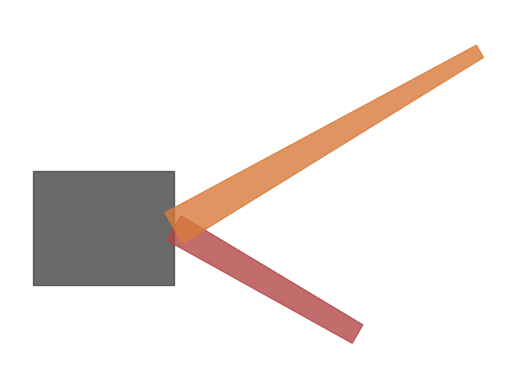

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


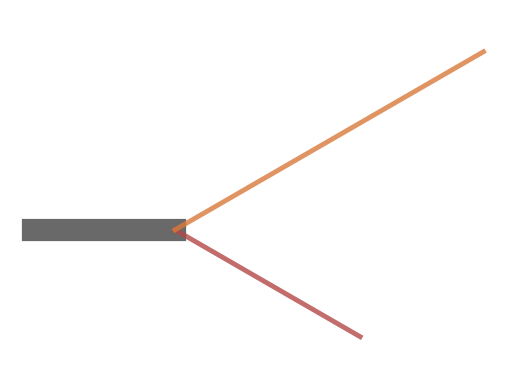

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


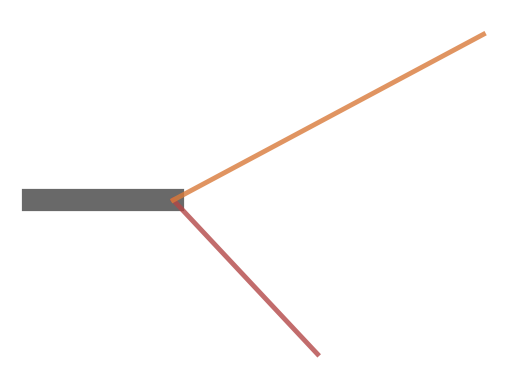

-----------------------------------
root         | soma
n_branches   | 3
geometry     | incomplete 3d points
length       | 100.00 um
area         | 1885.25 um^2
volume       | 4822.34 um^3
-----------------------------------

soma
├── basal
└── apical


In [3]:
demo_tree = demo_tree()
demo_tree.vis2d()
demo_tree.vis2d(shape = 'line')
demo_tree.vis2d(layout = 'stem', shape = 'line') 
print(demo_tree)
print(demo_tree.topo())

### 1.1 用 `radii_proximal` / `radii_distal` 按段指定半径

如果你想直接给每一段的近端半径和远端半径，可以用 `radii_proximal` / `radii_distal`。这和 `radii=[..., ...]` 是互斥的，二者不能同时传。

第 `i` 段的半径变化就是 `radii_proximal[i] -> radii_distal[i]`。这种写法在想按段描述 taper，或者需要表达段间半径跳变时更直接。

radii_proximal: 

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


[3. 2.] um
radii_distal: [2. 1.] um


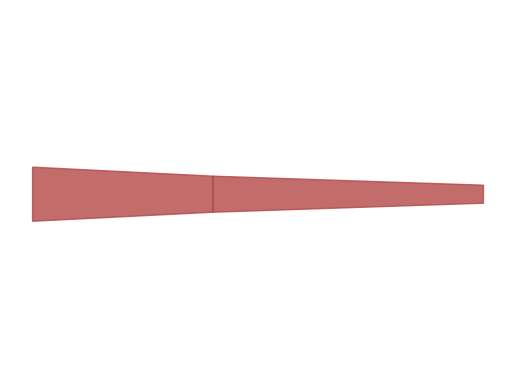

<Axes: >

In [4]:
paired_branch = Branch.from_lengths(
    lengths=[20.0, 30.0] * u.um,
    radii_proximal=[3.0, 2.0] * u.um,
    radii_distal=[2.0, 1.0] * u.um,
    type="basal_dendrite",
)
paired_tree = Morphology.from_root(paired_branch, name="dend")

print("radii_proximal:", paired_branch.radii_proximal)
print("radii_distal:", paired_branch.radii_distal)
paired_tree.vis2d()


### 2. 用 `Branch.from_points()` 创建带 3D 几何的 morphology

`from_points()` 适合已经有坐标点的场景。segment 长度会从相邻点自动计算出来，因此更接近真实重建数据。

这类 morphology 更适合做 `vis3d()`，也能用 `vis2d(layout="projected")` 看投影。

In [5]:
point_soma = Branch.from_points(
    points=[(0.0, 0.0, 0.0), (0.0, 12.0, 0.0)] * u.um,
    radii=[6.0, 6.0] * u.um,
    type="soma",
)
point_dend = Branch.from_points(
    points=[(0.0, 12.0, 0.0), (20.0, 32.0, 8.0)] * u.um,
    radii=[2.0, 1.0] * u.um,
    type="basal_dendrite",
)

point_tree = Morphology.from_root(point_soma, name="soma")
point_tree.soma.dend = point_dend

print("has_full_point_geometry:", point_tree.has_full_point_geometry)
print(point_tree.topo())
point_tree.vis3d(jupyter_backend="html")


has_full_point_geometry: True
soma
└── dend


2026-04-12 15:09:05.799 (   0.465s) [    7979B246F740]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=


EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

### 3. 从文件加载真实 morphology

实际建模更常见的是直接读取重建结果：
- `Morphology.from_swc(path)`：最常用。
- `Morphology.from_asc(path)`：适合 Neurolucida ASC。
- `Morphology.from_neuromorpho(neuron_id)`：直接按公开 neuron id 下载。

下面加载仓库里的一个 SWC 文件，并查看 3D 形态与拓扑。

In [6]:
tree = Morphology.from_swc("./morpho_files/bc.swc")
tree.vis3d(jupyter_backend="html")

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

In [7]:
print(tree.topo())

soma
├── basal_dendrite_0
│   ├── basal_dendrite_1
│   └── basal_dendrite_2
├── basal_dendrite_3
├── basal_dendrite_4
├── basal_dendrite_5
│   ├── basal_dendrite_6
│   └── basal_dendrite_7
│       ├── basal_dendrite_8
│       │   ├── basal_dendrite_9
│       │   └── basal_dendrite_10
│       │       ├── basal_dendrite_11
│       │       └── basal_dendrite_12
│       └── basal_dendrite_13
│           ├── basal_dendrite_14
│           └── basal_dendrite_15
│               ├── basal_dendrite_16
│               └── basal_dendrite_17
│                   ├── basal_dendrite_18
│                   └── basal_dendrite_19
│                       ├── basal_dendrite_20
│                       └── basal_dendrite_21
├── basal_dendrite_22
│   ├── basal_dendrite_23
│   └── basal_dendrite_24
│       ├── basal_dendrite_25
│       └── basal_dendrite_26
├── basal_dendrite_27
│   ├── basal_dendrite_28
│   │   ├── basal_dendrite_29
│   │   └── basal_dendrite_30
│   └── basal_dendrite_31
│       ├── basal_den

## 创建 Cell

`Cell(morphology, cv_policy=...)` 会先把 morphology 离散成一组 control volumes (CV)，然后在这些 CV 上继续配置 cable property、channel 和 point mechanism。

In [8]:
# CVPerBranch(2) 表示每个 branch 固定切成 2 个 CV。
cell = Cell(demo_tree, cv_policy=CVPerBranch(2))
print(cell)
cell.cvs

-----------------------------------
root           | soma
n_branches     | 3
n_cv           | 6
n_paint_rules  | 1
n_place_rules  | 0
-----------------------------------



(CV(id=0, branch_id=0, branch_type='soma', prox=0.0, dist=0.5, parent_cv=None, children_cv=(1,), length=Quantity(10., "um"), area=Quantity(502.65482, "um^2"), cm=Quantity(1., "uF / cm^2"), ra=Quantity(100., "cm * ohm"), v=Quantity(-65., "mV"), temp=Quantity(309.15, "K"), r_axial=Quantity(49735.918, "ohm"), r_axial_prox=Quantity(24867.959, "ohm"), r_axial_dist=Quantity(24867.959, "ohm"), density_mech=(), point_mech=(), _frusta=(CVFrustum(prox=0.0, dist=0.5, length=Quantity(10., "um"), radius_prox=Quantity(8., "um"), radius_dist=Quantity(8., "um"), point_prox=None, point_dist=None),)),
 CV(id=1, branch_id=0, branch_type='soma', prox=0.5, dist=1.0, parent_cv=0, children_cv=(2, 4), length=Quantity(10., "um"), area=Quantity(502.65482, "um^2"), cm=Quantity(1., "uF / cm^2"), ra=Quantity(100., "cm * ohm"), v=Quantity(-65., "mV"), temp=Quantity(309.15, "K"), r_axial=Quantity(49735.918, "ohm"), r_axial_prox=Quantity(24867.959, "ohm"), r_axial_dist=Quantity(24867.959, "ohm"), density_mech=(), poi

In [9]:
# MaxCVLen 会根据物理长度自动决定每个 branch 需要多少个 CV。
cell.cv_policy = MaxCVLen(15.0 * u.um)
print(cell)
print(cell.cvs)

-----------------------------------
root           | soma
n_branches     | 3
n_cv           | 11
n_paint_rules  | 1
n_place_rules  | 0
-----------------------------------

(CV(id=0, branch_id=0, branch_type='soma', prox=0.0, dist=0.3333333333333333, parent_cv=None, children_cv=(1,), length=Quantity(6.6666665, "um"), area=Quantity(335.1032, "um^2"), cm=Quantity(1., "uF / cm^2"), ra=Quantity(100., "cm * ohm"), v=Quantity(-65., "mV"), temp=Quantity(309.15, "K"), r_axial=Quantity(33157.28, "ohm"), r_axial_prox=Quantity(16578.64, "ohm"), r_axial_dist=Quantity(16578.64, "ohm"), density_mech=(), point_mech=(), _frusta=(CVFrustum(prox=0.0, dist=0.3333333333333333, length=Quantity(6.6666665, "um"), radius_prox=Quantity(8., "um"), radius_dist=Quantity(8., "um"), point_prox=None, point_dist=None),)), CV(id=1, branch_id=0, branch_type='soma', prox=0.3333333333333333, dist=0.6666666666666666, parent_cv=0, children_cv=(2,), length=Quantity(6.6666665, "um"), area=Quantity(335.1032, "um^2"), cm=Quanti

In [10]:
# Cell 默认已经有一条全局 cable property 规则，这里只演示如何局部覆盖。
cell.paint(
    BranchSlice(branch_index=0, prox=0.0, dist=1.0),
    CableProperty(
        resting_potential=-70.0 * u.mV,
        membrane_capacitance=2.0 * (u.uF / u.cm ** 2),
        axial_resistivity=150.0 * (u.ohm * u.cm),
        temperature=u.celsius2kelvin(30.0),
    ),
)
cell.paint_rules

(PaintRule(region=AllRegion(), mechanism=CableProperty(resting_potential=Quantity(-65., "mV"), membrane_capacitance=Quantity(1., "uF / cm^2"), axial_resistivity=Quantity(100., "cm * ohm"), temperature=Quantity(309.15, "K"))),
 PaintRule(region=BranchSlice(branch_index=0, prox=0.0, dist=1.0), mechanism=CableProperty(resting_potential=Quantity(-70., "mV"), membrane_capacitance=Quantity(2., "uF / cm^2"), axial_resistivity=Quantity(150., "cm * ohm"), temperature=Quantity(303.15, "K"))))

## Declarative mechanism API

`braincell.mech` is a purely-declarative layer for recording *what* to install
on a `Cell` before the runtime is compiled. Every mechanism declaration is a
frozen value — channels, ions, clamps, probes, and synapses all live under a
common `Mechanism` base class and split into two subtrees:

- **`Density`** — distributed membrane mechanisms painted onto a region.
  Concrete subclasses are `Channel` (ion channels) and `Ion` (ion species).
  Both accept the target class as either a string (`"IL"`) or the Python class
  itself (`braincell.channel.IL`); the first form routes through the mechanism
  registry, the second is looked up by identity.
- **`Point`** — point mechanisms placed onto a locset. Concrete subclasses
  are `CurrentClamp`, `SineClamp`, `FunctionClamp`, `ProbeMechanism`,
  `Synapse`, and `Junction` (gap junction).

`CableProperty` is painted separately to configure passive cable properties.
Order-insensitive `Params` hashing means `Channel("IL", g_max=..., E=...)` and
`Channel("IL", E=..., g_max=...)` deduplicate into the same paint-layout
group.

In [11]:
cell = Cell(tree, cv_policy=CVPerBranch(2))

# Paint a leak channel everywhere. The keyword argument form accepts the
# concrete class directly (braincell.channel.IL) in addition to the string
# "IL"; both route through the mechanism registry to the same runtime class.
cell.paint(
    AllRegion(),
    braincell.mech.Channel(braincell.channel.IL, g_max=0.1 * (u.mS / u.cm ** 2), E=-70.0 * u.mV),
)

# Paint HH sodium + potassium onto soma, basal dendrite, and axon regions.
# braincell.mech.Channel / Ion are now real classes (inheriting from
# braincell.mech.Density) rather than factory functions, but the calling
# convention is unchanged — parameters arrive as keyword arguments.
for region in (
    BranchInFilter("type", "soma"),
    BranchInFilter("type", "basal_dendrite"),
    BranchInFilter("type", "axon"),
):
    cell.paint(
        region,
        braincell.mech.Channel("INa_HH1952", g_max=120 * (u.mS / u.cm ** 2)),
        braincell.mech.Channel("IK_HH1952", g_max=36 * (u.mS / u.cm ** 2)),
    )

# Place a current clamp at the root using the CurrentClamp.step() shortcut
# for the common single-pulse case. The canonical multi-segment form with
# (start, durations, amplitudes) is still available when needed.
cell.place(
    RootLocation(x=0.5),
    braincell.CurrentClamp.step(0.3 * u.nA, 100.0 * u.ms, delay=50.0 * u.ms),
)

cell.init_state()

In [12]:
dt = 0.1 * u.ms
tstop = 200 * u.ms


def step_fun(t):
    with brainstate.environ.context(t=t):
        cell.update()
    v_next = cell.V.value
    return v_next

cell.reset_state()

with brainstate.environ.context(dt=dt):
    times = u.math.arange(0.0 * u.ms, tstop, brainstate.environ.get_dt())
    v_seq = brainstate.transform.for_loop(step_fun, times)

v_mV = np.asarray(v_seq / u.mV, dtype=float)

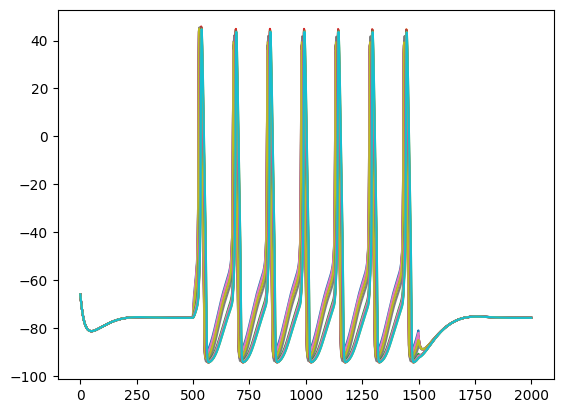

In [13]:
for i in range(200):
    if i % 10 == 0:
        plt.plot(v_mV[:, i])
plt.show()